HESOC MARK RESULTS


In [1]:
%matplotlib ipympl

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.3f}'.format

In [2]:
def get_files(dir):
    return sorted(dir.glob('t1-*.txt'))

In [3]:
def parse_baseline(dir, file):
    baseline_data = None
    baseline_df = None
    baseline_file = dir / file
    if baseline_file.exists():
        print(f'\nBaseline trovato: {baseline_file.name}')
        baseline_data = {'size': [], 'value': []}
        with open(baseline_file, 'r') as f:
            for line in f:
                if line.startswith('HESOCMARK:'):
                    parts = line.strip().split()
                    if len(parts) >= 3:
                        baseline_data['size'].append(int(parts[1]))
                        baseline_data['value'].append(float(parts[2]))
        baseline_df = pd.DataFrame(baseline_data)
    else:
        print('\nNessun file baseline.txt trovato')
    
    return (baseline_data, baseline_df)

In [4]:
def format_bytes(x, pos):
    """Format bytes to KB/MB with proper binary suffix"""
    if x >= 1048576:  # >= 1 MB
        return f'{x/1048576:.0f}MB'
    elif x >= 1024:  # >= 1 KB
        return f'{x/1024:.0f}KB'
    else:
        return f'{int(x)}B'

In [7]:
def plot_graphs(path, label):
    (baseline_data, baseline_df) = parse_baseline(path, 'baseline.txt')

    files = get_files(path)

    # Create separate figure for this file
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot baseline first if available (as background reference)
    if baseline_data:
        ax.plot(baseline_df['size'], baseline_df['value'], marker='s', markersize=4, 
                linewidth=1.5, color="#21c0dc", alpha=0.5, linestyle='--', label='Baseline')
        
    # Parse and plot data - separate plot for each file
    for file in files:
        # Read and parse the file
        data = {'size': [], 'value': []}
        
        with open(file, 'r') as f:
            for line in f:
                if line.startswith('HESOCMARK:'):
                    # Parse line: "HESOCMARK: 1024	1.12"
                    parts = line.strip().split()
                    if len(parts) >= 3:
                        size = int(parts[1])
                        value = float(parts[2])
                        data['size'].append(size)
                        data['value'].append(value)
        
        # Create DataFrame
        df = pd.DataFrame(data)
        
        # Extract label from filename
        data_label = file.stem.replace('t1-', '').replace('.sh_1', '').replace('_', ' ').strip()
        print(data_label)
        
        # Plot with log scale on x-axis
        ax.plot(df['size'], df['value'], label=data_label, marker='o', markersize=5, 
                linewidth=2, alpha=0.8)
        
    # Configure plot
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Size (bytes)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latency', fontsize=12, fontweight='bold')
    ax.set_title(f'HESOCMARK Benchmark: {label}', fontsize=14, fontweight='bold')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(left=0, right=64000000)
    ax.legend()

    ax.xaxis.set_major_formatter(FuncFormatter(format_bytes))

    ax.axvline(x=65536, color='red')
    ax.axvline(x=1089536, color='orange')
    
    plt.tight_layout()
    plt.show()


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


/tmp/ipykernel_1367/2896259181.py:47: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(left=0, right=64000000)


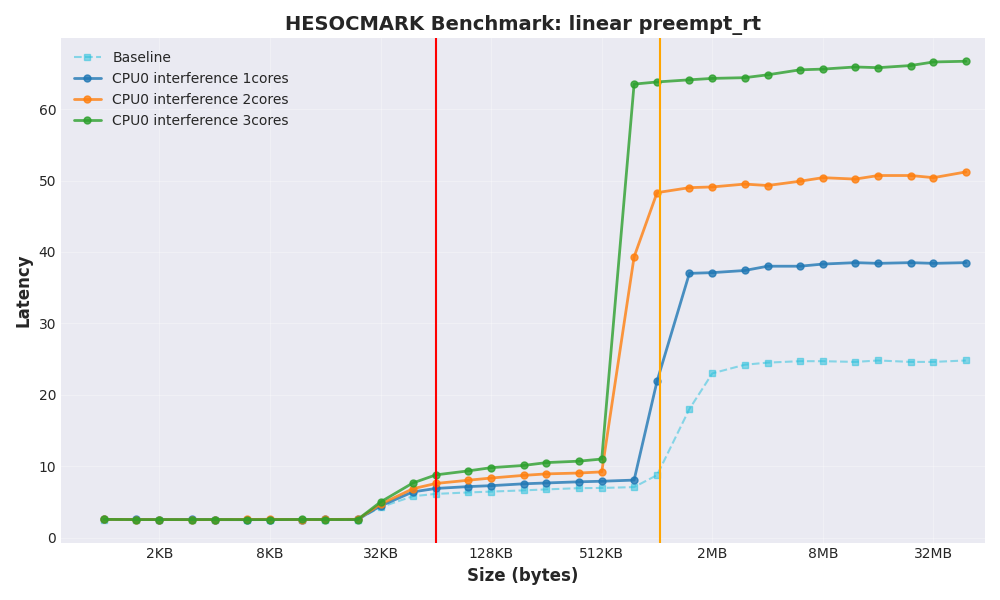


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


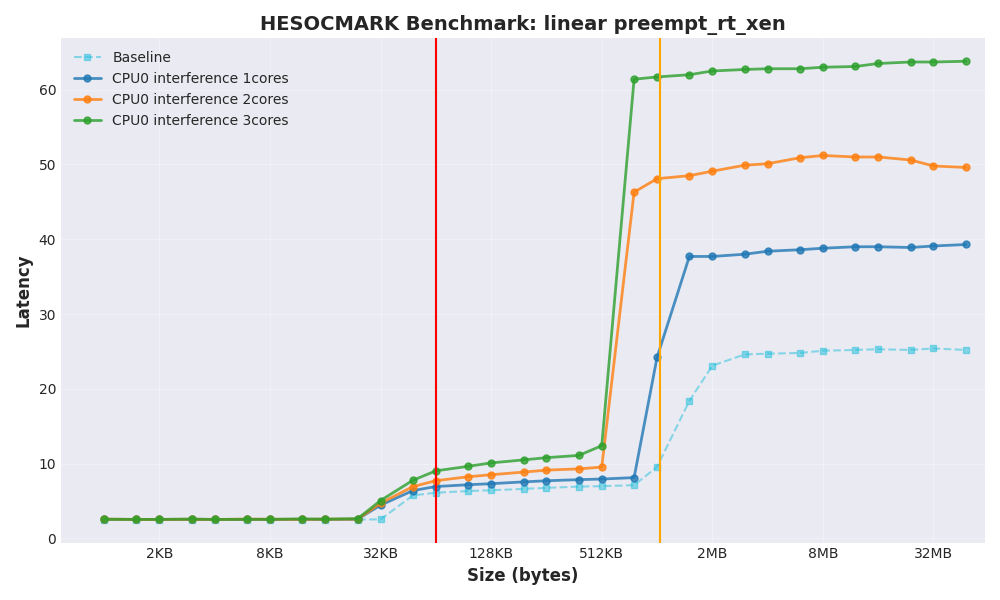


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


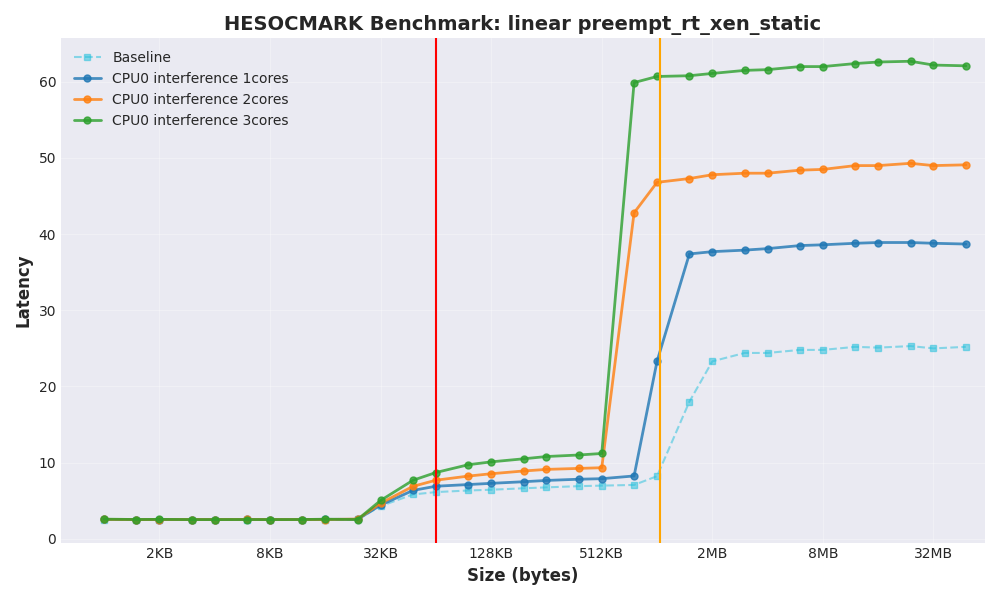


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


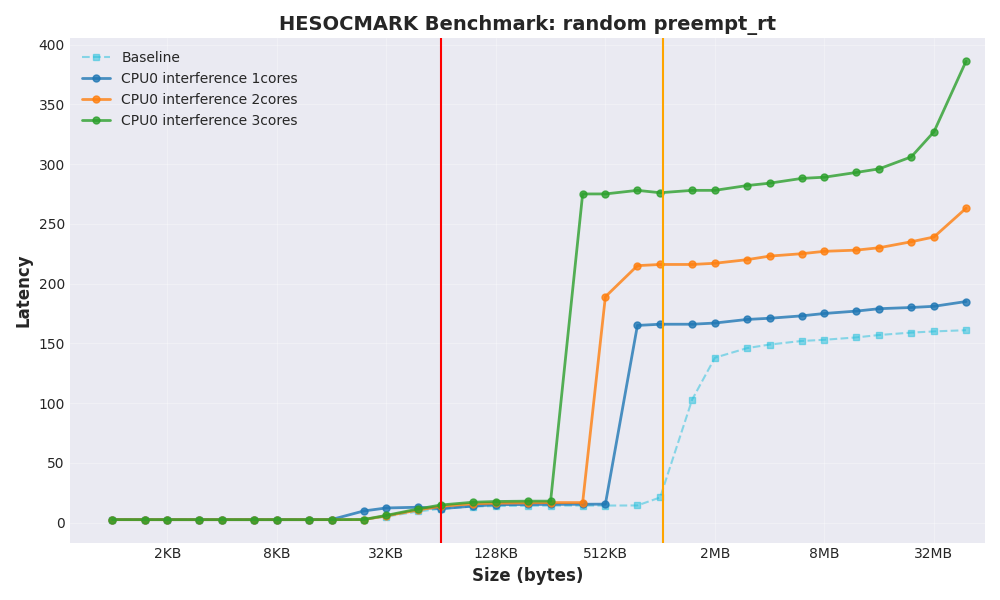


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


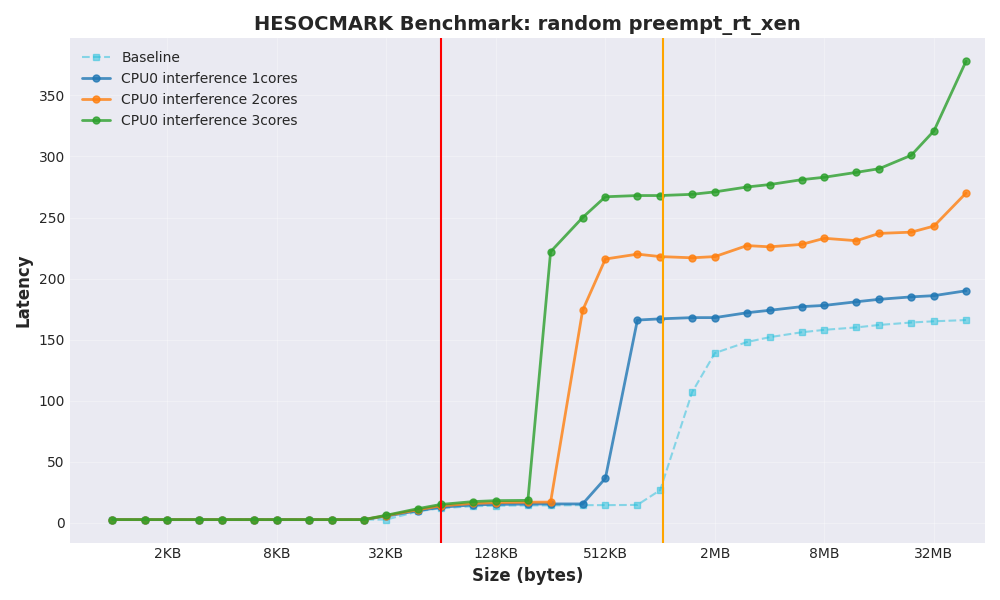


Baseline trovato: baseline.txt
CPU0 interference 1cores
CPU0 interference 2cores
CPU0 interference 3cores


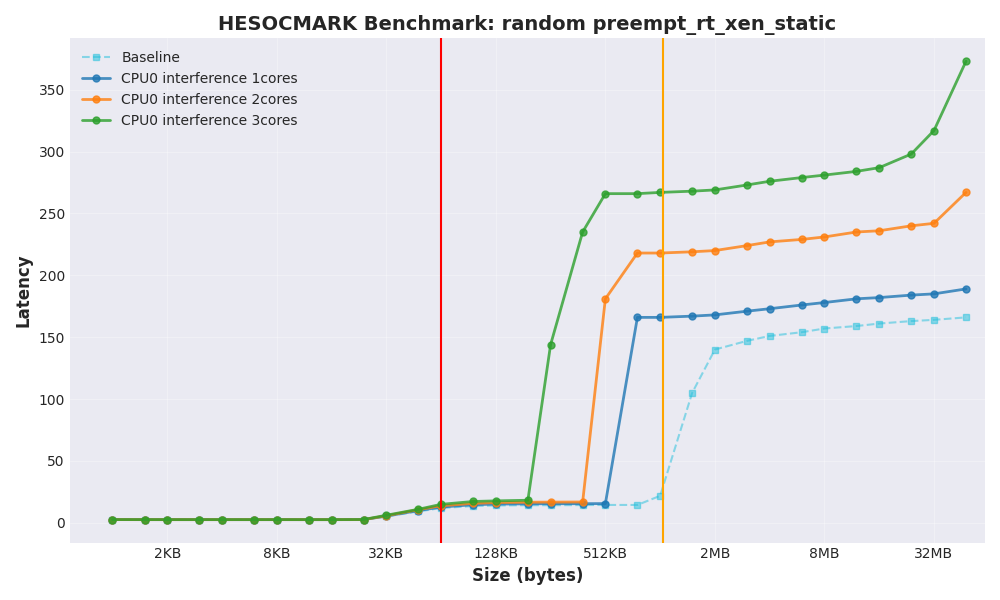

In [8]:
DATA_FOLDER = Path('./data_memory')

modes = [x for x in DATA_FOLDER.iterdir() if x.is_dir()]

for mode in modes:
    cases = [x for x in mode.iterdir() if x.is_dir()]
    for case in cases:
        plot_graphs(case, f'{mode.name} {case.name}')
        